<a href="https://colab.research.google.com/github/marina-popova11/MambaModelPrediction/blob/train/mamba_3clases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install causal-conv1d==1.4.0 && pip install mamba-ssm==2.2.2 --no-build-isolation

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 946.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 45.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 38.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 71.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [1]:
!pip install mamba-ssm --no-build-isolation
!pip install mamba-ssm[causal-conv1d] --no-build-isolation

In [2]:
try:
    import mamba_ssm
    print("✅ mamba_ssm импортируется успешно")
    print("Версия:", mamba_ssm.__version__)
except Exception as e:
    print(f"❌ Ошибка импорта: {e}")
    print("\nПроверка деталей:")
    !python -c "import sys; print(sys.version)"
    !nvcc --version

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/dis

✅ mamba_ssm импортируется успешно
Версия: 2.2.2


/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [3]:
!pip install transformers torch
!pip install pandas numpy scikit-learn tqdm torch matplotlib

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import pickle
import os

In [31]:
import pandas as pd
import numpy as np

def create_features(df, lookback=24, norm_window=24):
    """Создание признаков для временного ряда
    Вход: Log-Return + Z-score
    Выход: Log-Return (будущий)"""
    df = df.copy()

    df['returns'] = df['Close'].pct_change()
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    rolling_mean = df['log_return'].rolling(window=norm_window).mean()
    rolling_std = df['log_return'].rolling(window=norm_window).std()
    df['norm_return'] = (df['log_return'] - rolling_mean) / (rolling_std + 1e-9)

    for lag in [1, 2, 3, 6, 12, 24]:
        df[f'norm_return_lag_{lag}'] = df['norm_return'].shift(lag)

    df['norm_return_sma_12'] = df['norm_return'].rolling(12).mean()
    df['norm_return_sma_24'] = df['norm_return'].rolling(24).mean()
    df['norm_return_ema_12'] = df['norm_return'].ewm(span=12).mean()

    df['volatility_returns'] = df['returns'].rolling(window=lookback).std()
    df['volatility_log'] = df['log_return'].rolling(window=lookback).std()
    df['rsi'] = compute_rsi_stable(df['log_return'], period=14)

    long_vol = df['log_return'].rolling(window=lookback*3).std()
    df['vol_ratio'] = df['volatility_log'] / (long_vol + 1e-9)

    for lag in [1, 2, 3]:
        df[f'log_return_lag_{lag}'] = df['log_return'].shift(lag)

    forecast_horizon = 24
    future_close = df['Close'].shift(-forecast_horizon)
    current_close = df['Close']
    df['target_return'] = np.log(future_close / current_close.shift(-1))
    df['target_direction'] = (df['target_return'] > 0).astype(int)

    df['volume_ma'] = df['Volume'].rolling(24).mean()
    df['volume_ratio'] = df['Volume'] / (df['volume_ma'] + 1e-9)

    vol_rolling_mean = df['Volume'].rolling(window=norm_window).mean()
    vol_rolling_std = df['Volume'].rolling(window=norm_window).std()
    df['volume_norm'] = (df['Volume'] - vol_rolling_mean) / (vol_rolling_std + 1e-9)

    df.dropna(inplace=True)
    return df

def compute_rsi_stable(prices, period=14):
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).ewm(alpha=1/period, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/period, adjust=False).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def create_discrete_targets_threshold(df, target_col='target_return', vol_col='volatility_log'):
    """Дискретизация по квантилям — в каждом бине равное количество токенов"""
    df = df.copy()

    threshold = df[vol_col].median() * 1.7

    conditions = [
        df[target_col] < -threshold,      # down
        df[target_col] > threshold,       # up
    ]
    choices = ['down', 'up']

    df['target_class'] = np.select(conditions, choices, default='neutral')
    df['target_class'] = df['target_class'].astype('category')

    print(f"\n3-class distribution:")
    print(df['target_class'].value_counts(normalize=True))

    return df

In [19]:
import pandas as pd
df = pd.read_csv("btc_1h_data_2020-2025.csv")
print(df.shape, df.columns)
print(df.head(5))

(51926, 12) Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')
                   Open time     Open     High      Low    Close      Volume  \
0  2020-01-01 00:00:00+00:00  7195.24  7196.25  7175.46  7177.02  511.814901   
1  2020-01-01 01:00:00+00:00  7176.47  7230.00  7175.71  7216.27  883.052603   
2  2020-01-01 02:00:00+00:00  7215.52  7244.87  7211.41  7242.85  655.156809   
3  2020-01-01 03:00:00+00:00  7242.66  7245.00  7220.00  7225.01  783.724867   
4  2020-01-01 04:00:00+00:00  7225.00  7230.00  7215.03  7217.27  467.812578   

                  Close time  Quote asset volume  Number of trades  \
0  2020-01-01 01:00:00+00:00        3.675857e+06              7640   
1  2020-01-01 02:00:00+00:00        6.365953e+06              9033   
2  2020-01-01 03:00:00+00:00        4.736719e+06              7466   

In [32]:
new_df = create_features(df)
df_with_classes = create_discrete_targets_threshold(new_df)
print(new_df.shape, new_df.columns)
print(new_df.head(5))
target_clean = df_with_classes['target_return'].clip(
    lower=df_with_classes['target_return'].quantile(0.01),
    upper=df_with_classes['target_return'].quantile(0.99)
)
print("\nМедианная доходность по классам:")
print(df_with_classes.groupby('target_class')['target_return'].median())
print(df_with_classes.head(5))


3-class distribution:
target_class
up         0.348100
neutral    0.343218
down       0.308682
Name: proportion, dtype: float64
(51830, 36) Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore', 'returns', 'log_return',
       'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
       'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
       'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
       'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
       'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
       'target_return', 'target_direction', 'volume_ma', 'volume_ratio',
       'volume_norm'],
      dtype='object')
                    Open time     Open     High      Low    Close  \
72  2020-01-04 00:00:00+00:00  7345.00  7350.00  7289.98  7302.24   
73  2020-

/tmp/ipykernel_16660/3480630478.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_with_classes.groupby('target_class')['target_return'].median())


In [33]:
df_with_classes.to_csv("btc_1h_2020-2025_training_sample_with_bins_second.csv", index=False)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def prepare_data_internal(df, lookback=60, n_bins=3, classification_mode=True):
    df = df.sort_values('Open time').reset_index(drop=True)
    df['Open time'] = pd.to_datetime(df['Open time'])
    if classification_mode:
        if 'target_class' not in df.columns:
            raise ValueError("Колонка 'target_class' не найдена. Запустите сначала create_discrete_targets_quantile.")

        target_col_raw = 'target_class'

        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df['target_encoded'] = le.fit_transform(df[target_col_raw])
        print("LabelEncoder classes order:")
        for i, cls in enumerate(le.classes_):
            print(f"  {i} → {cls}")

        target_col = 'target_encoded'
        class_labels = list(le.classes_) # Сохраняем порядок классов: ['neutral', 'strong_down'...]

        class_medians = df.groupby(target_col)['target_return'].median().to_dict()
        print(f"\nClass medians: {class_medians}")
    else:
        target_col = 'target_return'
        class_labels = None
        class_medians = None

    feature_cols = [
        'Open', 'High', 'Low', 'Close', 'Volume',
        'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
        'Taker buy quote asset volume', 'returns', 'log_return',
        'norm_return', 'norm_return_lag_1', 'norm_return_lag_2',
        'norm_return_lag_3', 'norm_return_lag_6', 'norm_return_lag_12',
        'norm_return_lag_24', 'norm_return_sma_12', 'norm_return_sma_24',
        'norm_return_ema_12', 'volatility_returns', 'volatility_log', 'rsi',
        'vol_ratio', 'log_return_lag_1', 'log_return_lag_2', 'log_return_lag_3',
        'volume_ma', 'volume_ratio', 'volume_norm'
    ]

    feature_cols = [col for col in feature_cols if col in df.columns]

    df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

    total_len = len(df)
    train_end = int(total_len * 0.70)
    val_end = int(total_len * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    print("\n=== DATE RANGE CHECK ===")
    for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        print(f"{name}: {split_df['Open time'].min()} to {split_df['Open time'].max()}")

    if train_df['Open time'].max() < val_df['Open time'].min() < test_df['Open time'].min():
        print("Dates are strictly sequential (no leakage).")
    else:
        print("WARNING: Date overlap or gap detected!")

    from sklearn.preprocessing import RobustScaler
    scaler_features = RobustScaler(quantile_range=(10.0, 90.0))

    scaler_features.fit(train_df[feature_cols])
    train_scaled = scaler_features.transform(train_df[feature_cols])
    val_scaled = scaler_features.transform(val_df[feature_cols])
    test_scaled = scaler_features.transform(test_df[feature_cols])

    if classification_mode:
        y_train = train_df[target_col].values.astype(np.int64)
        y_val = val_df[target_col].values.astype(np.int64)
        y_test = test_df[target_col].values.astype(np.int64)
    else:
        from sklearn.preprocessing import StandardScaler
        scaler_target = StandardScaler()
        scaler_target.fit(train_df[[target_col]])
        y_train = scaler_target.transform(train_df[[target_col]]).flatten()
        y_val = scaler_target.transform(val_df[[target_col]]).flatten()
        y_test = scaler_target.transform(test_df[[target_col]]).flatten()

    def create_windows(features, targets):
        X, y = [], []
        for i in range(lookback, len(features)):
            X.append(features[i-lookback:i])
            y.append(targets[i])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64 if classification_mode else np.float32)

    X_train, y_train = create_windows(train_scaled, y_train)
    X_val, y_val = create_windows(val_scaled, y_val)
    X_test, y_test = create_windows(test_scaled, y_test)

    time_train = df['Open time'].iloc[lookback:train_end].values
    time_val = df['Open time'].iloc[train_end+lookback:val_end].values
    time_test = df['Open time'].iloc[val_end+lookback:].values

    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    if classification_mode:
        unique, counts = np.unique(y_train, return_counts=True)
        print(f"Class distribution in Train: {dict(zip(unique, counts))}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler_features': scaler_features,
        'feat_cols': feature_cols,
        'time_index': {'train': time_train, 'val': time_val, 'test': time_test},
        'classification_mode': classification_mode,
        'class_labels': class_labels,      # Чтобы знать, что класс 0 - это 'neutral' и т.д.
        'class_medians': class_medians,    # Чтобы понимать среднюю доходность класса
        'n_classes': n_bins if classification_mode else None,
        'target_col': target_col
    }

In [6]:
def get_data_loaders(filename, lookback=60, batch_size=128, cache_file='data_cache.pkl',
                     n_bins=5, classification_mode=True, force_reprocess=False):
    cache_key = f"{cache_file}_{lookback}_{n_bins}_{classification_mode}"

    if os.path.exists(cache_key) and not force_reprocess:
        print(f"Загрузка кэшированных данных из {cache_key}...")
        with open(cache_key, 'rb') as f:
            data_dict = pickle.load(f)
    else:
        print(f"Обработка данных из {filename} (это займет время)...")
        df = pd.read_csv(filename)
        data_dict = prepare_data_internal(df, lookback, n_bins, classification_mode)

        with open(cache_key, 'wb') as f:
            pickle.dump(data_dict, f)
        print(f"Кэш сохранен в {cache_key}")

    def make_loader(X, y, shuffle=False):
        if classification_mode:
            dataset = TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
        else:
            dataset = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(data_dict['X_train'], data_dict['y_train'], shuffle=True)
    val_loader = make_loader(data_dict['X_val'], data_dict['y_val'], shuffle=False)
    test_loader = make_loader(data_dict['X_test'], data_dict['y_test'], shuffle=False)

    print(f"Данные готовы: Train={len(data_dict['X_train'])}, Val={len(data_dict['X_val'])}, Test={len(data_dict['X_test'])}")
    print(f"Режим: {'Классификация' if classification_mode else 'Регрессия'}")
    if classification_mode:
        print(f"Количество классов: {data_dict['n_classes']}")
        unique, counts = np.unique(data_dict['y_train'], return_counts=True)
        print(f"Распределение классов в train: {dict(zip(unique, counts))}")

    return data_dict, train_loader, val_loader, test_loader

In [7]:
import torch.nn as nn
import torch.optim as optim

class MambaModel(nn.Module):
    def __init__(self, input_dim, n_classes=3,  d_model=128, n_layers=2, use_mamba=True):
        super().__init__()
        self.use_mamba = use_mamba
        self.n_classes = n_classes
        self.drop1 = nn.Dropout(0.1)
        self.input_proj = nn.Linear(input_dim, d_model)

        if use_mamba:
            try:
                from mamba_ssm import Mamba
                print("Using Mamba Architecture")
                self.blocks = nn.ModuleList([
                    Mamba(d_model=d_model, d_state=8, d_conv=4, expand=1)
                    for _ in range(n_layers)
                ])
            except ImportError:
                print("Mamba not installed. Falling back to LSTM.")
                self.use_mamba = False

        if not self.use_mamba:
            print("Using LSTM Architecture (Fallback)")
            self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model, num_layers=n_layers, batch_first=True, dropout=0.0)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(d_model // 2, n_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)
        if isinstance(self.blocks, nn.ModuleList):
            for block in self.blocks:
                x = block(x)
        else:
            x, _ = self.lstm(x)
        x = self.norm(x)
        last_hidden = x[:, -1, :]
        logits = self.head(last_hidden)
        return logits

In [13]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def run_training_classification(model, train_loader, val_loader, epochs=20,
                                learning_rate=5e-5, early_stop_patience=10,
                                model_path="best_mamba_classifier.pth",
                                class_weights=None):
    device = next(model.parameters()).device
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)

    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print("\nStarting Training(Classification)...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)  # [batch, n_classes]
            loss = criterion(logits, yb)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"DETECTED NaN/Inf Loss! Stopping.")
                return None

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            train_total += yb.size(0)
            train_correct += (predicted == yb).sum().item()

        train_loss /= len(train_loader)
        train_acc = train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                val_loss += loss.item()

                _, predicted = torch.max(logits, 1)
                val_total += yb.size(0)
                val_correct += (predicted == yb).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch + 1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            torch.save({
                'model_state_dict': model.state_dict(),
                'best_val_acc': best_val_acc,
                'best_val_loss': best_val_loss,
                'epoch': epoch
            }, model_path)
            print(f"-> Saved best model! (Val Acc: {val_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    print(f"\nTraining finished. Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")
    return history

In [9]:
import torch
import torch.nn as nn
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_classification(model, test_loader, class_medians, class_labels,
                            time_index=None, model_path="best_mamba_classifier.pth"):
    print("Keys in class_medians:", list(class_medians.keys()))
    print("Expected class indices:", list(range(len(class_labels))))
    assert set(class_medians.keys()) == set(range(len(class_labels))), "Mismatch!"
    device = next(model.parameters()).device

    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"\nEvaluating on Test Set... (Best Val Acc: {checkpoint['best_val_acc']:.4f})")

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1)  # [batch, n_classes]
            preds = torch.argmax(logits, dim=1)  # [batch]

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)

    accuracy = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_targets, all_preds)

    print(f"\n=== CLASSIFICATION RESULTS ===")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print(f"Weighted F1-Score: {f1:.4f}")
    print(f"\nClassification Report:")
    report = classification_report(all_targets, all_preds,
                                   target_names=class_labels,
                                   zero_division=0)
    print(report)

    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2%})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

    if class_medians:
        pred_log_returns = np.array([class_medians[p] for p in all_preds])
        true_log_returns = np.array([class_medians[t] for t in all_targets])
        rmse_log = np.sqrt(np.mean((pred_log_returns - true_log_returns) ** 2))
        mae_log = np.mean(np.abs(pred_log_returns - true_log_returns))

        print(f"\n=== PRICE SPACE METRICS (using class medians) ===")
        print(f"RMSE (log-return): {rmse_log:.6f}")
        print(f"MAE (log-return): {mae_log:.6f}")
        print(f"Это соответствует ошибке в цене ~ {mae_log * 100:.2f}%")

        pred_direction = np.sign(pred_log_returns)
        true_direction = np.sign(true_log_returns)
        dir_accuracy = np.mean(pred_direction == true_direction)
        print(f"Direction Accuracy: {dir_accuracy:.4f} ({dir_accuracy:.2%})")

        if time_index is not None and len(time_index) == len(all_targets):
            fig, axes = plt.subplots(2, 1, figsize=(14, 10))

            # График 1: Сравнение классов
            axes[0].plot(time_index, all_targets, label='Actual Class', color='blue', alpha=0.6)
            axes[0].plot(time_index, all_preds, label='Predicted Class', color='red', alpha=0.6, linestyle='--')
            axes[0].set_ylabel('Class Index')
            axes[0].set_title(f'Class Predictions (Accuracy: {accuracy:.2%})')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # График 2: Log-returns (через медианы)
            axes[1].plot(time_index, true_log_returns, label='Actual Log-Return', color='blue', alpha=0.7)
            axes[1].plot(time_index, pred_log_returns, label='Predicted Log-Return', color='red', alpha=0.7, linestyle='--')
            axes[1].set_ylabel('Log-Return')
            axes[1].set_title(f'Log-Returns from Class Medians (Dir Acc: {dir_accuracy:.2%})')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig('classification_results.png', dpi=150)
            plt.show()

    return accuracy, f1

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

def evaluate_baseline_most_frequent(y_train, y_test):
    """Всегда предсказываем самый частый класс из трейна"""
    most_freq = np.bincount(y_train).argmax()
    preds = np.full_like(y_test, most_freq)
    return {
        'name': 'Most Frequent Class',
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds, average='weighted', zero_division=0)
    }

def evaluate_baseline_random(y_train, y_test, n_classes):
    """Случайное угадывание с учётом распределения классов в трейне"""
    # Эмулируем случайный выбор с тем же распределением, что в трейне
    probs = np.bincount(y_train, minlength=n_classes) / len(y_train)
    preds = np.random.choice(n_classes, size=len(y_test), p=probs)
    return {
        'name': 'Random (weighted)',
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds, average='weighted', zero_division=0)
    }

def evaluate_baseline_feature_simple(X_train, y_train, X_test, y_test, n_classes):
    """
    Простой логистический регрессор на последних признаках.
    Это ЧЕСТНЫЙ базлайн: использует те же признаки, что и модель.
    """
    # Берём только последний временной шаг из lookback-окна
    # X имеет форму [samples, lookback, features], берем [:, -1, :]
    X_train_last = X_train[:, -1, :]
    X_test_last = X_test[:, -1, :]

    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_train_last, y_train)

    preds = clf.predict(X_test_last)
    return {
        'name': 'LogReg (last step)',
        'accuracy': accuracy_score(y_test, preds),
        'f1': f1_score(y_test, preds, average='weighted', zero_division=0)
    }

def run_baselines_comparison_fair(data_dict, model_preds=None):
    """Честное сравнение: только информация, доступная в момент t"""
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']
    X_train = data_dict['X_train']  # [samples, lookback, features]
    X_test = data_dict['X_test']

    # Вычисляем реальное количество классов
    n_classes = int(max(y_train.max(), y_test.max())) + 1

    print(f"Обнаружено {n_classes} уникальных классов")

    results = [
        evaluate_baseline_random(y_train, y_test, n_classes),
        evaluate_baseline_most_frequent(y_train, y_test),
        evaluate_baseline_feature_simple(X_train, y_train, X_test, y_test, n_classes),
    ]

    if model_preds is not None:
        # Защита от выходов за пределы
        model_preds = np.clip(model_preds, 0, n_classes - 1)
        results.append({
            'name': 'Mamba Model',
            'accuracy': accuracy_score(y_test, model_preds),
            'f1': f1_score(y_test, model_preds, average='weighted', zero_division=0)
        })

    print("\n" + "="*70)
    print("FAIR BASELINE COMPARISON (Test Set)")
    print("Только информация, доступная в момент прогноза (t)")
    print("="*70)
    print(f"{'Model':<30} {'Accuracy':>12} {'F1 (w)':>12}")
    print("-"*70)
    for r in sorted(results, key=lambda x: x['accuracy'], reverse=True):
        print(f"{r['name']:<30} {r['accuracy']:>12.4f} {r['f1']:>12.4f}")
    print("="*70)

    # Интерпретация
    best_baseline = max(results[:-1] if model_preds is not None else results, key=lambda x: x['accuracy'])
    model_result = results[-1] if model_preds is not None else None

    if model_result:
        diff = model_result['accuracy'] - best_baseline['accuracy']
        if diff > 0.03:
            print(f"Модель превзошла лучший базлайн на {diff*100:.2f}%")
        elif diff > -0.02:
            print(f"Модель на уровне базлайна — сигнал слабый, но есть")
        else:
            print(f"Модель хуже базлайна на {-diff*100:.2f}%")
            print("   Возможные причины:")
            print("   • Недообучение (мало эпох, высокий LR)")
            print("   • Переобучение (мало данных, сложная модель)")
            print("   • Признаки не несут сигнала для горизонта 24ч")

    return results

In [11]:
def get_model_predictions(model, test_loader, model_path="best_mamba_classifier.pth"):
    """Загружает лучшую модель и возвращает предсказания для тестовой выборки"""
    device = next(model.parameters()).device
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    all_preds = []

    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds)

In [28]:
!pip show mamba-ssm

Name: mamba-ssm
Version: 2.2.2
Summary: Mamba state-space model
Home-page: https://github.com/state-spaces/mamba
Author: Tri Dao, Albert Gu
Author-email: tri@tridao.me, agu@cs.cmu.edu
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: einops, ninja, packaging, torch, transformers, triton
Required-by: 


Обработка данных из btc_1h_2020-2025_training_sample_with_bins_second.csv (это займет время)...
LabelEncoder classes order:
  0 → down
  1 → neutral
  2 → up

Class medians: {0: -0.022099795083121, 1: 0.0001732182452589, 2: 0.02286811941187155}

=== DATE RANGE CHECK ===
Train: 2020-01-04 00:00:00+00:00 to 2024-02-25 00:00:00+00:00
Val: 2024-02-25 01:00:00+00:00 to 2025-01-13 22:00:00+00:00
Test: 2025-01-13 23:00:00+00:00 to 2025-12-03 21:00:00+00:00
Dates are strictly sequential (no leakage).
Train shape: (36161, 120, 31), Val shape: (7654, 120, 31), Test shape: (7655, 120, 31)
Class distribution in Train: {np.int64(0): np.int64(11283), np.int64(1): np.int64(12150), np.int64(2): np.int64(12728)}
Кэш сохранен в processed_data_cache.pkl_120_3_True
Данные готовы: Train=36161, Val=7654, Test=7655
Режим: Классификация
Количество классов: 3
Распределение классов в train: {np.int64(0): np.int64(11283), np.int64(1): np.int64(12150), np.int64(2): np.int64(12728)}
Class weights: tensor([1.0683, 

Epoch 1/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 249.66it/s]


Epoch 1: Train Loss=1.0832, Train Acc=0.3980 | Val Loss=1.1341, Val Acc=0.3160
-> Saved best model! (Val Acc: 0.3160)


Epoch 2/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 229.98it/s]


Epoch 2: Train Loss=1.0703, Train Acc=0.4135 | Val Loss=1.1193, Val Acc=0.3184
-> Saved best model! (Val Acc: 0.3184)


...

Epoch 15: Train Loss=1.0384, Train Acc=0.4506 | Val Loss=1.1208, Val Acc=0.3207


Epoch 16/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 214.95it/s]


Epoch 16: Train Loss=1.0391, Train Acc=0.4524 | Val Loss=1.1271, Val Acc=0.3232


Epoch 17/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 255.16it/s]


Epoch 17: Train Loss=1.0381, Train Acc=0.4520 | Val Loss=1.1213, Val Acc=0.3232
Early stopping at epoch 17

Training finished. Best Val Acc: 0.3383, Best Val Loss: 1.1069
Keys in class_medians: [0, 1, 2]
Expected class indices: [0, 1, 2]

Evaluating on Test Set... (Best Val Acc: 0.3383)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.3317 (33.17%)
Weighted F1-Score: 0.3321

Classification Report:
              precision    recall  f1-score   support

        down       0.29      0.37      0.32      2251
     neutral       0.41      0.29      0.34      3080
          up       0.32      0.36      0.34      2324

    accuracy                           0.33      7655
   macro avg       0.34      0.34      0.33      7655
weighted avg       0.34      0.33      0.33      7655



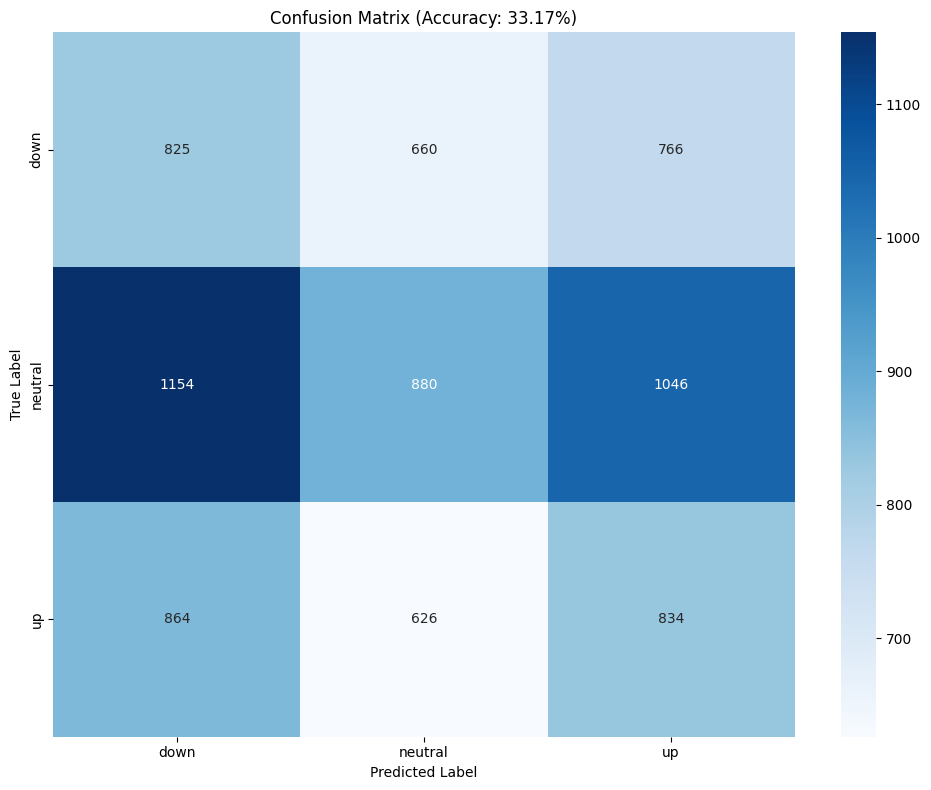


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.025703
MAE (log-return): 0.019810
Это соответствует ошибке в цене ~ 1.98%
Direction Accuracy: 0.5501 (55.01%)


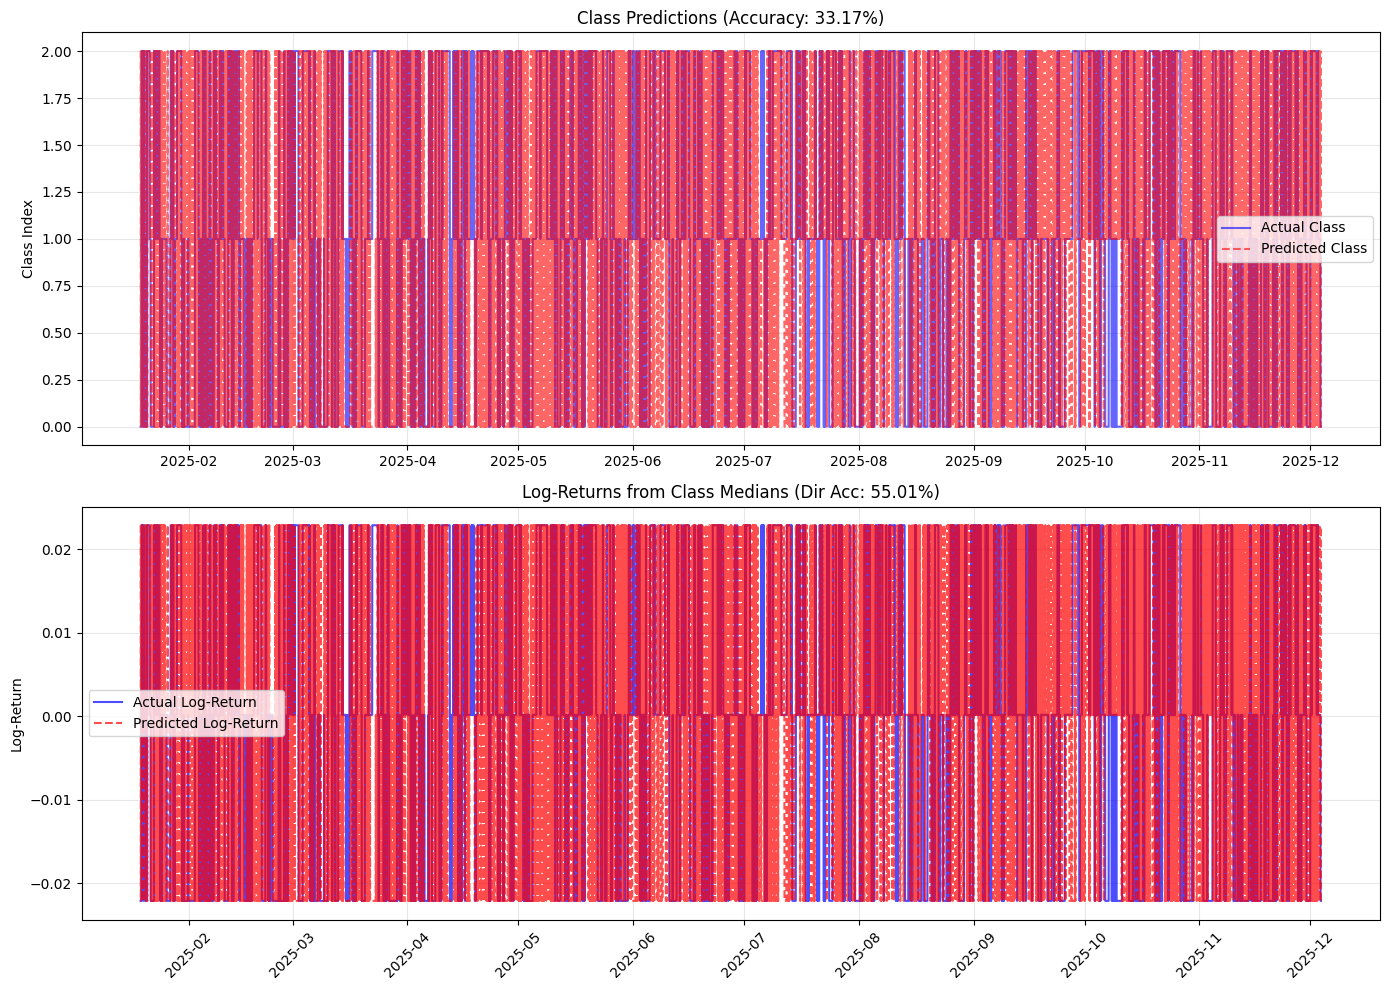


Получение предсказаний модели для сравнения с Baseline...
Обнаружено 3 уникальных классов

FAIR BASELINE COMPARISON (Test Set)
Только информация, доступная в момент прогноза (t)
Model                              Accuracy       F1 (w)
----------------------------------------------------------------------
Random (weighted)                    0.3374       0.3390
Mamba Model                          0.3317       0.3321
Most Frequent Class                  0.3036       0.1414
LogReg (last step)                   0.2941       0.1336
Модель на уровне базлайна — сигнал слабый, но есть


In [34]:
# для 3 классов, acc = 33, dir acc = 55
if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 50
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 3
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins_second.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    X_train_flat = data_dict['X_train'][:, -1, :]
    X_test_flat = data_dict['X_test'][:, -1, :]
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_flat, y_train)
    y_pred = clf.predict(X_test_flat)

    print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    model = MambaModel(
        input_dim=input_dim,
        n_classes=n_classes,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        use_mamba=True
    ).to(device)

    history = run_training_classification(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        learning_rate=1e-4,
        early_stop_patience=10,
        model_path=MODEL_PATH,
        class_weights=class_weights_tensor
    )

    if history is not None:
        evaluate_classification(
            model=model,
            test_loader=test_loader,
            class_medians=class_medians,
            class_labels=class_labels,
            time_index=data_dict['time_index']['test'],
            model_path=MODEL_PATH
        )

        print("\nПолучение предсказаний модели для сравнения с Baseline...")
        model_preds_array = get_model_predictions(model, test_loader, MODEL_PATH)
        run_baselines_comparison_fair(data_dict, model_preds=model_preds_array)

Обработка данных из btc_1h_2020-2025_training_sample_with_bins_second.csv (это займет время)...
LabelEncoder classes order:
  0 → down
  1 → neutral
  2 → up

Class medians: {0: -0.0210806156002079, 1: 0.0001643162590336, 2: 0.02192835671181885}

=== DATE RANGE CHECK ===
Train: 2020-01-04 00:00:00+00:00 to 2024-02-25 00:00:00+00:00
Val: 2024-02-25 01:00:00+00:00 to 2025-01-13 22:00:00+00:00
Test: 2025-01-13 23:00:00+00:00 to 2025-12-03 21:00:00+00:00
Dates are strictly sequential (no leakage).
Train shape: (36161, 120, 31), Val shape: (7654, 120, 31), Test shape: (7655, 120, 31)
Class distribution in Train: {np.int64(0): np.int64(11844), np.int64(1): np.int64(11033), np.int64(2): np.int64(13284)}
Кэш сохранен в processed_data_cache.pkl_120_3_True
Данные готовы: Train=36161, Val=7654, Test=7655
Режим: Классификация
Количество классов: 3
Распределение классов в train: {np.int64(0): np.int64(11844), np.int64(1): np.int64(11033), np.int64(2): np.int64(13284)}
Class weights: tensor([1.0177,

Epoch 1/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 262.80it/s]


Epoch 1: Train Loss=1.0825, Train Acc=0.3949 | Val Loss=1.1101, Val Acc=0.3347
-> Saved best model! (Val Acc: 0.3347)


Epoch 2/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 256.84it/s]


Epoch 2: Train Loss=1.0709, Train Acc=0.4069 | Val Loss=1.1215, Val Acc=0.3405
-> Saved best model! (Val Acc: 0.3405)


...

Epoch 14: Train Loss=1.0406, Train Acc=0.4456 | Val Loss=1.2391, Val Acc=0.3356


Epoch 15/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 242.18it/s]


Epoch 15: Train Loss=1.0378, Train Acc=0.4522 | Val Loss=1.2810, Val Acc=0.3346


Epoch 16/50 [Val]: 100%|██████████| 60/60 [00:00<00:00, 246.61it/s]


Epoch 16: Train Loss=1.0354, Train Acc=0.4518 | Val Loss=1.2593, Val Acc=0.3410
Early stopping at epoch 16

Training finished. Best Val Acc: 0.3477, Best Val Loss: 1.1231
Keys in class_medians: [0, 1, 2]
Expected class indices: [0, 1, 2]

Evaluating on Test Set... (Best Val Acc: 0.3477)

=== CLASSIFICATION RESULTS ===
Accuracy: 0.3366 (33.66%)
Weighted F1-Score: 0.2995

Classification Report:
              precision    recall  f1-score   support

        down       0.32      0.69      0.43      2399
     neutral       0.37      0.21      0.27      2765
          up       0.41      0.14      0.21      2491

    accuracy                           0.34      7655
   macro avg       0.36      0.35      0.30      7655
weighted avg       0.37      0.34      0.30      7655



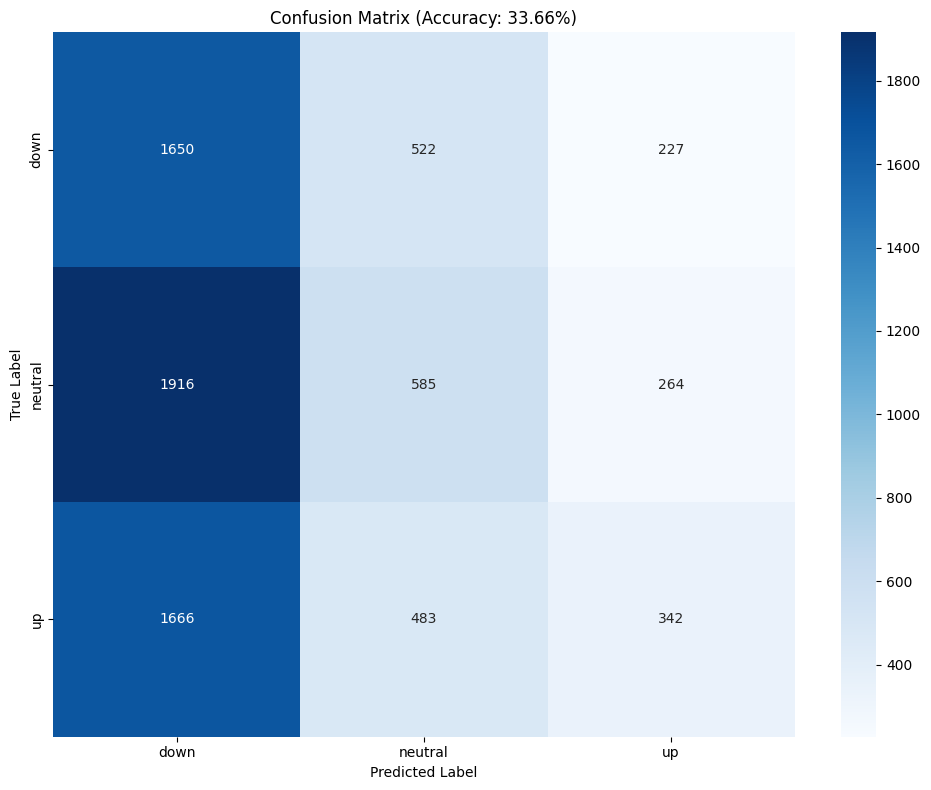


=== PRICE SPACE METRICS (using class medians) ===
RMSE (log-return): 0.025444
MAE (log-return): 0.019526
Это соответствует ошибке в цене ~ 1.95%
Direction Accuracy: 0.4342 (43.42%)


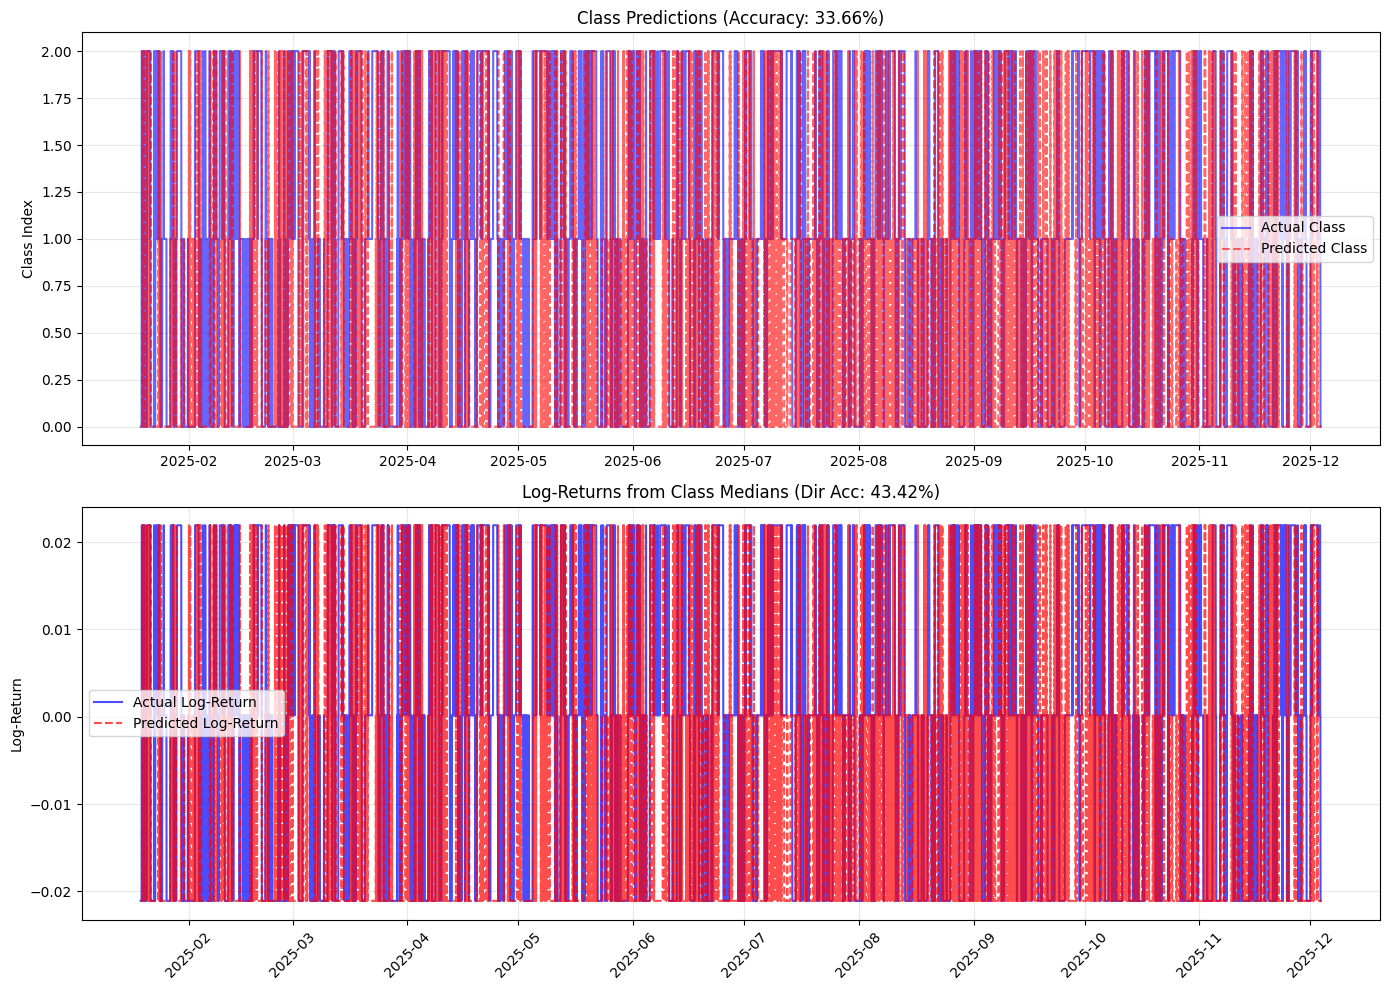


Получение предсказаний модели для сравнения с Baseline...
Обнаружено 3 уникальных классов

FAIR BASELINE COMPARISON (Test Set)
Только информация, доступная в момент прогноза (t)
Model                              Accuracy       F1 (w)
----------------------------------------------------------------------
Mamba Model                          0.3366       0.2995
Most Frequent Class                  0.3254       0.1598
Random (weighted)                    0.3228       0.3223
LogReg (last step)                   0.3134       0.1496
Модель на уровне базлайна — сигнал слабый, но есть


In [16]:
# для 3 классов, acc = 33, dir acc = 46
if __name__ == "__main__":
    LOOKBACK = 120
    BATCH_SIZE = 128
    EPOCHS = 50
    D_MODEL = 128
    N_LAYERS = 2
    N_BINS = 3
    CSV_FILE = 'btc_1h_2020-2025_training_sample_with_bins_second.csv'
    CACHE_FILE = 'processed_data_cache.pkl'
    MODEL_PATH = 'best_mamba_classifier.pth'

    data_dict, train_loader, val_loader, test_loader = get_data_loaders(
        filename=CSV_FILE,
        lookback=LOOKBACK,
        batch_size=BATCH_SIZE,
        cache_file=CACHE_FILE,
        n_bins=N_BINS,
        classification_mode=True,
        force_reprocess=False
    )

    input_dim = data_dict['X_train'].shape[2]
    n_classes = data_dict['n_classes']
    class_labels = data_dict['class_labels']
    class_medians = data_dict['class_medians']

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_np = compute_class_weight('balanced', classes=np.unique(data_dict['y_train']), y=data_dict['y_train'])
    class_weights_tensor = torch.FloatTensor(class_weights_np)
    print(f"Class weights: {class_weights_tensor}")

    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score

    X_train_flat = data_dict['X_train'][:, -1, :]
    X_test_flat = data_dict['X_test'][:, -1, :]
    y_train = data_dict['y_train']
    y_test = data_dict['y_test']

    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_flat, y_train)
    y_pred = clf.predict(X_test_flat)

    print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    model = MambaModel(
        input_dim=input_dim,
        n_classes=n_classes,
        d_model=D_MODEL,
        n_layers=N_LAYERS,
        use_mamba=True
    ).to(device)

    history = run_training_classification(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        learning_rate=1e-4,
        early_stop_patience=10,
        model_path=MODEL_PATH,
        class_weights=class_weights_tensor
    )

    if history is not None:
        evaluate_classification(
            model=model,
            test_loader=test_loader,
            class_medians=class_medians,
            class_labels=class_labels,
            time_index=data_dict['time_index']['test'],
            model_path=MODEL_PATH
        )

        print("\nПолучение предсказаний модели для сравнения с Baseline...")
        model_preds_array = get_model_predictions(model, test_loader, MODEL_PATH)
        run_baselines_comparison_fair(data_dict, model_preds=model_preds_array)